# Algoritmos - Actividad Guiada 1

**Alumno:** Ricardo Germes Serrano  
**Nombre:** Raúl Reyero  
**URL:** https://colab.research.google.com/drive/1lJqfBFQFbfb39vkg9KlMqWj527tXl9uY?usp=sharing  
**Repositorio:** http://github.com/rauxxxx/Algoritmos

## Torres de Hanoi con Divide y Vencerás

In [1]:
def Torres_Hanoi(N, desde, hasta):
  if N ==1 :
    print("Lleva la ficha " ,desde , " hasta ", hasta )

  else:
    #Torres_Hanoi(N-1, desde, 6-desde-hasta )
    Torres_Hanoi(N-1, desde, 6-desde-hasta )
    print("Lleva la ficha " ,desde , " hasta ", hasta )
    #Torres_Hanoi(N-1,6-desde-hasta, hasta )
    Torres_Hanoi(N-1, 6-desde-hasta  , hasta )


In [2]:
# Versión con auxiliar por parámetro
def Torres_Hanoi_v1(N, origen, auxiliar, destino):
  if N == 1 :
    print(f"Lleva la ficha {N} desde {origen} a {destino}")

  else:
    Torres_Hanoi_v1(N-1, origen, auxiliar, destino )
    print(f"Lleva la ficha {N} desde {origen} a {destino}")
    Torres_Hanoi_v1(N-1, auxiliar , destino, origen )


In [3]:
# Bateria de pruebas

print(f"Torres de Hanoi:")
Torres_Hanoi(3, 1, 3)
print()
print(f"Torres de Hanoi con auxiliar parametrizado:")
Torres_Hanoi_v1(3, 1 , 2,  3)
print()
print(f"Torres de Hanoi con auxiliar parametrizado no numérico:")
Torres_Hanoi_v1(3, "A" , "B", "C")


Torres de Hanoi:
Lleva la ficha  1  hasta  3
Lleva la ficha  1  hasta  2
Lleva la ficha  3  hasta  2
Lleva la ficha  1  hasta  3
Lleva la ficha  2  hasta  1
Lleva la ficha  2  hasta  3
Lleva la ficha  1  hasta  3

Torres de Hanoi con auxiliar parametrizado:
Lleva la ficha 1 desde 1 a 3
Lleva la ficha 2 desde 1 a 3
Lleva la ficha 1 desde 2 a 1
Lleva la ficha 3 desde 1 a 3
Lleva la ficha 1 desde 2 a 1
Lleva la ficha 2 desde 2 a 1
Lleva la ficha 1 desde 3 a 2

Torres de Hanoi con auxiliar parametrizado no numérico:
Lleva la ficha 1 desde A a C
Lleva la ficha 2 desde A a C
Lleva la ficha 1 desde B a A
Lleva la ficha 3 desde A a C
Lleva la ficha 1 desde B a A
Lleva la ficha 2 desde B a A
Lleva la ficha 1 desde C a B


In [4]:
#Sucesión_de_Fibonacci
#https://es.wikipedia.org/wiki/Sucesi%C3%B3n_de_Fibonacci
#Calculo del termino n-simo de la suscesión de Fibonacci
def Fibonacci(N:int):
  if N < 2:
    return 1
  else:
    return Fibonacci(N-1)+Fibonacci(N-2)


In [5]:
# Mejora por memorización en caché para evitar calculos repetidos 
# La recursión pura recalcula los mismos subproblemas una y otra vez (Fibonacci(3) se llama múltiples veces dentro de Fibonacci(5), etc.). 
# Para N grandes (30+) se vuelve extremadamente lento.
from functools import lru_cache

@lru_cache(maxsize=None)
def Fibonacci_v1(N: int):
    if N < 2:
        return 1
    return Fibonacci_v1(N-1) + Fibonacci_v1(N-2)
    

In [6]:
# Programación dinámica iterativa (bottom-up), O(n) tiempo y O(1) memoria:
def Fibonacci_v2(N: int):
    a, b = 1, 1
    for _ in range(N):
        a, b = b, a + b
    return a


In [7]:
# Bateria de pruebas FIBONACCI

print("Fibonacci original:")
print(f"Fibonacci(5) = {Fibonacci(5)}")
print(f"Fibonacci(30) = {Fibonacci(30)}")
print()
print("Fibonacci usando cache:")
print(f"Fibonacci(5) = {Fibonacci_v1(5)}")
print(f"Fibonacci(30) = {Fibonacci_v1(30)}")
print()
print("Fibonacci prog. iterativa:")
print(f"Fibonacci(5) = {Fibonacci_v2(5)}") 
print(f"Fibonacci(30) = {Fibonacci_v2(30)}")


Fibonacci original:
Fibonacci(5) = 8
Fibonacci(30) = 1346269

Fibonacci usando cache:
Fibonacci(5) = 8
Fibonacci(30) = 1346269

Fibonacci prog. iterativa:
Fibonacci(5) = 8
Fibonacci(30) = 1346269


## Devolución de Cambio por Técnica Voraz

In [8]:
def cambio_monedas(N, SM):
  SOLUCION = [0]*len(SM)   #SOLUCION = [0,0,0,0,..]
  ValorAcumulado = 0

  for i,valor in enumerate(SM):
    monedas =  (N-ValorAcumulado)//valor
    SOLUCION[i] = monedas
    ValorAcumulado = ValorAcumulado + monedas*valor

    if ValorAcumulado == N:
      return SOLUCION
      

In [9]:
# MEJORA: En la versión anterior, si no existe solución exacta con el sistema de monedas dado, 
#         la función no entra nunca en el if ValorAcumulado == N y termina devolviendo None implícitamente sin avisar. 
#         Ejemplo: cambio_monedas(3, [25,10]) falla silenciosamente.
def cambio_monedas_v1(N, SM):
    SOLUCION = [0]*len(SM)
    ValorAcumulado = 0

    for i, valor in enumerate(SM):
        monedas = (N - ValorAcumulado) // valor
        SOLUCION[i] = monedas
        ValorAcumulado += monedas * valor
        if ValorAcumulado == N:
            return SOLUCION

    return(f"No es posible formar {N} con el sistema de monedas {SM}") 



In [10]:
# Bateria de pruebas CAMBIO DE MONEDAS
C = 15
M = [25,10,5,1]
print(f"Cambio de {C} con sistema de monedas de {M} = {cambio_monedas(C,M)}")
print(f"Cambio de {C} con sistema de monedas de {M} = {cambio_monedas_v1(C,M)}")

print()

C = 3
M = [25,10]
print(f"Cambio de {C} con sistema de monedas de {M} = {cambio_monedas(C,M)}")
print(f"Cambio de {C} con sistema de monedas de {M} = {cambio_monedas_v1(C,M)}")


Cambio de 15 con sistema de monedas de [25, 10, 5, 1] = [0, 1, 1, 0]
Cambio de 15 con sistema de monedas de [25, 10, 5, 1] = [0, 1, 1, 0]

Cambio de 3 con sistema de monedas de [25, 10] = None
Cambio de 3 con sistema de monedas de [25, 10] = No es posible formar 3 con el sistema de monedas [25, 10]


## N-Reinas por Técnica de Vuelta Atrás

In [11]:
def escribe(S):
  n = len(S)
  for x in range(n):
    print("")
    for i in range(n):
      if S[i] == x+1:
        print(" X " , end="")
      else:
        print(" - ", end="")


def es_prometedora(SOLUCION,etapa):
  #print(SOLUCION)
  #Si la solución tiene dos valores iguales no es valida => Dos reinas en la misma fila
  for i in range(etapa+1):
    #print("El valor " + str(SOLUCION[i]) + " está " +  str(SOLUCION.count(SOLUCION[i])) + " veces")
    if SOLUCION.count(SOLUCION[i]) > 1:
      return False

    #Verifica las diagonales
    for j in range(i+1, etapa +1 ):
      #print("Comprobando diagonal de " + str(i) + " y " + str(j))
      if abs(i-j) == abs(SOLUCION[i]-SOLUCION[j]) : return False
  return True



def reinas(N, solucion=[], etapa=0):
  if len(solucion) == 0:
      solucion=[0 for i in range(N)]

  for i in range(1, N+1):
    solucion[etapa] = i

    if es_prometedora(solucion, etapa):
      if etapa == N-1:
        print(solucion)
        #escribe(solucion)
        #print()
      else:
        reinas(N, solucion, etapa+1)
    else:
      None

    solucion[etapa] = 0


In [12]:
# MEJORA:
#        Problema actual: es_prometedora se llama en cada intento y recorre desde i=0 todas las reinas colocadas hasta la etapa actual, 
#        y dentro de eso vuelve a comparar todas contra todas — es decir, revalida reinas que ya sabías que eran compatibles entre sí en la llamada anterior. Además SOLUCION.count(...) recorre todo el array cada vez. Esto añade un factor de sobrecoste innecesario sobre un algoritmo que ya es exponencial de por sí.

# Mejora clave: solo necesitamos comprobar la reina que acabamos de colocar (etapa) contra las anteriores, no todas contra todas:

def es_prometedora_v1(solucion, etapa):
    for i in range(etapa):
        if solucion[i] == solucion[etapa]:          # misma columna
            return False
        if abs(i - etapa) == abs(solucion[i] - solucion[etapa]):  # misma diagonal
            return False
    return True

def reinas_v1(N, solucion=[], etapa=0):
  if len(solucion) == 0:
      solucion=[0 for i in range(N)]

  for i in range(1, N+1):
    solucion[etapa] = i

    if es_prometedora_v1(solucion, etapa):
      if etapa == N-1:
        print(solucion)
        #escribe(solucion)
        #print()
      else:
        reinas(N, solucion, etapa+1)
    else:
      None

    solucion[etapa] = 0


In [13]:
# MEJORA: Mejora más avanzada: Usar conjuntos para columnas y diagonales ocupadas, evitando el bucle de comprobación por completo:
def reinas_v2(N, solucion=None, etapa=0, columnas=None, diag1=None, diag2=None):
    if solucion is None:
        solucion, columnas, diag1, diag2 = [0]*N, set(), set(), set()

    for col in range(1, N+1):
        d1, d2 = etapa - col, etapa + col
        if col in columnas or d1 in diag1 or d2 in diag2:
            continue
        solucion[etapa] = col
        columnas.add(col); diag1.add(d1); diag2.add(d2)

        if etapa == N-1:
            print(solucion)
            escribe(solucion)
            print()
        else:
            #escribe(solucion)
            #print()
            reinas_v2(N, solucion, etapa+1, columnas, diag1, diag2)

        columnas.discard(col); diag1.discard(d1); diag2.discard(d2)


In [14]:
# Bateria de pruebas REINAS

print("Soluciones reinas original para 8x8:")
%time reinas(8)
print()
print("Soluciones reinas v1 para 8x8:")
%time reinas_v1(8)
print()
print("Soluciones reinas v2 con detalle para 8x8:")
%time reinas_v2(8)


Soluciones reinas original para 8x8:
[1, 5, 8, 6, 3, 7, 2, 4]
[1, 6, 8, 3, 7, 4, 2, 5]
[1, 7, 4, 6, 8, 2, 5, 3]
[1, 7, 5, 8, 2, 4, 6, 3]
[2, 4, 6, 8, 3, 1, 7, 5]
[2, 5, 7, 1, 3, 8, 6, 4]
[2, 5, 7, 4, 1, 8, 6, 3]
[2, 6, 1, 7, 4, 8, 3, 5]
[2, 6, 8, 3, 1, 4, 7, 5]
[2, 7, 3, 6, 8, 5, 1, 4]
[2, 7, 5, 8, 1, 4, 6, 3]
[2, 8, 6, 1, 3, 5, 7, 4]
[3, 1, 7, 5, 8, 2, 4, 6]
[3, 5, 2, 8, 1, 7, 4, 6]
[3, 5, 2, 8, 6, 4, 7, 1]
[3, 5, 7, 1, 4, 2, 8, 6]
[3, 5, 8, 4, 1, 7, 2, 6]
[3, 6, 2, 5, 8, 1, 7, 4]
[3, 6, 2, 7, 1, 4, 8, 5]
[3, 6, 2, 7, 5, 1, 8, 4]
[3, 6, 4, 1, 8, 5, 7, 2]
[3, 6, 4, 2, 8, 5, 7, 1]
[3, 6, 8, 1, 4, 7, 5, 2]
[3, 6, 8, 1, 5, 7, 2, 4]
[3, 6, 8, 2, 4, 1, 7, 5]
[3, 7, 2, 8, 5, 1, 4, 6]
[3, 7, 2, 8, 6, 4, 1, 5]
[3, 8, 4, 7, 1, 6, 2, 5]
[4, 1, 5, 8, 2, 7, 3, 6]
[4, 1, 5, 8, 6, 3, 7, 2]
[4, 2, 5, 8, 6, 1, 3, 7]
[4, 2, 7, 3, 6, 8, 1, 5]
[4, 2, 7, 3, 6, 8, 5, 1]
[4, 2, 7, 5, 1, 8, 6, 3]
[4, 2, 8, 5, 7, 1, 3, 6]
[4, 2, 8, 6, 1, 3, 5, 7]
[4, 6, 1, 5, 2, 8, 3, 7]
[4, 6, 8, 2, 7, 1, 3, 5]
[4, 6, 8, 3, 

## Viaje por el Río. Programación Dinámica

In [15]:
TARIFAS = [
[0,5,4,3,999,999,999],
[999,0,999,2,3,999,11],
[999,999, 0,1,999,4,10],
[999,999,999, 0,5,6,9],
[999,999, 999,999,0,999,4],
[999,999, 999,999,999,0,3],
[999,999,999,999,999,999,0]
]



################################################################
def Precios(TARIFAS):
################################################################
  #Total de Nodos
  N = len(TARIFAS[0])

  #Inicialización de la tabla de precios
  PRECIOS = [ [9999]*N for i in [9999]*N]
  RUTA = [ [""]*N for i in [""]*N]

  for i in range(0,N-1):
    RUTA[i][i] = i             #Para ir de i a i se "pasa por i"
    PRECIOS[i][i] = 0          #Para ir de i a i se se paga 0
    for j in range(i+1, N):
      MIN = TARIFAS[i][j]
      RUTA[i][j] = i

      for k in range(i, j):
        if PRECIOS[i][k] + TARIFAS[k][j] < MIN:
            MIN = min(MIN, PRECIOS[i][k] + TARIFAS[k][j] )
            RUTA[i][j] = k          #Anota que para ir de i a j hay que pasar por k
        PRECIOS[i][j] = MIN

  return PRECIOS,RUTA
################################################################


PRECIOS,RUTA = Precios(TARIFAS)
#print(PRECIOS[0][6])

print("PRECIOS")
for i in range(len(TARIFAS)):
  print(PRECIOS[i])

print("\nRUTA")
for i in range(len(TARIFAS)):
  print(RUTA[i])

#Determinar la ruta con Recursividad
def calcular_ruta(RUTA, desde, hasta):
  if desde == hasta:
    #print("Ir a :" + str(desde))
    return ""
  else:
    return str(calcular_ruta( RUTA, desde, RUTA[desde][hasta])) +  \
                ',' + \
                str(RUTA[desde][hasta] \
              )

print("\nLa ruta es:")
calcular_ruta(RUTA, 0,6)

PRECIOS
[0, 5, 4, 3, 8, 8, 11]
[9999, 0, 999, 2, 3, 8, 7]
[9999, 9999, 0, 1, 6, 4, 7]
[9999, 9999, 9999, 0, 5, 6, 9]
[9999, 9999, 9999, 9999, 0, 999, 4]
[9999, 9999, 9999, 9999, 9999, 0, 3]
[9999, 9999, 9999, 9999, 9999, 9999, 9999]

RUTA
[0, 0, 0, 0, 1, 2, 5]
['', 1, 1, 1, 1, 3, 4]
['', '', 2, 2, 3, 2, 5]
['', '', '', 3, 3, 3, 3]
['', '', '', '', 4, 4, 4]
['', '', '', '', '', 5, 5]
['', '', '', '', '', '', '']

La ruta es:


',0,2,5'

## Puntos más Cercanos — Solución Completa

In [16]:
# Imports Comunes
import math
import random
import time
from itertools import combinations
import pandas as pd
import matplotlib.pyplot as plt


### Parte 1: Caso 1D — Lista de Números

#### Primer intento: Fuerza bruta

Comparamos todos los pares posibles y nos quedamos con la distancia mínima.

**Complejidad:** dos bucles anidados → <u>O(n²)</u>.

In [17]:
def cercanos_fuerza_bruta_1d(puntos):
    n = len(puntos)
    mejor_dist = float('inf')
    mejor_par = None
    for i in range(n):
        for j in range(i+1, n):
            d = abs(puntos[i] - puntos[j])
            if d < mejor_dist:
                mejor_dist = d
                mejor_par = (puntos[i], puntos[j])
    return mejor_par, mejor_dist
    

**Mejora:** si ordenamos la lista, el par más cercano siempre está formado por dos elementos consecutivos en el orden (si no fueran consecutivos, habría un punto entre medias que estaría más cerca de alguno de los dos). Eso ya te da una solución en <u>O(n log n)</u>:

In [18]:
def cercanos_ordenado_1d(puntos):
    p = sorted(puntos)
    mejor_dist = float('inf')
    mejor_par = None
    for i in range(len(p) - 1):
        d = p[i+1] - p[i]
        if d < mejor_dist:
            mejor_dist = d
            mejor_par = (p[i], p[i+1])
    return mejor_par, mejor_dist


#### Segundo intento: Divide y Vencerás

Este caso es interesante porque en 1D el Divide y Vencerás **no** mejora la versión ordenada de arriba — ambas son O(n log n) — pero su implementación proporciona exactamente la estructura que necesitaremos para 2D y 3D, donde el truco de "ordenar y mirar vecinos" ya no basta.

In [19]:
def cercanos_dyv_1d(puntos):
    p = sorted(puntos)

    def rec(sub):
        n = len(sub)
        if n <= 3:
            return cercanos_fuerza_bruta_1d(sub)

        mid = n // 2
        punto_medio = sub[mid]

        par_izq, dist_izq = rec(sub[:mid])
        par_der, dist_der = rec(sub[mid:])

        mejor_par, mejor_dist = (par_izq, dist_izq) if dist_izq < dist_der else (par_der, dist_der)

        # franja: puntos que podrían formar un par mejor cruzando la división
        franja = [x for x in sub if abs(x - punto_medio) < mejor_dist]
        for i in range(len(franja) - 1):
            d = franja[i+1] - franja[i]
            if d < mejor_dist:
                mejor_dist = d
                mejor_par = (franja[i], franja[i+1])

        return mejor_par, mejor_dist

    return rec(p)


### Parte 2: Caso 2D — Lista de Números

Aquí sí que el divide y vencerás demuestra su valor: la fuerza bruta sigue siendo O(n²), pero ahora no hay un simple "ordenar y mirar vecinos" que resuelva el problema en O(n log n), porque "cercano" ya no es un orden lineal.

#### Primer intento: Fuerza bruta

**Complejidad:** <u>O(n²)</u>.

In [20]:
def distancia(p1, p2):
    return math.hypot(p1[0]-p2[0], p1[1]-p2[1])

def cercanos_fuerza_bruta_2d(puntos):
    n = len(puntos)
    mejor_dist = float('inf')
    mejor_par = None
    for i in range(n):
        for j in range(i+1, n):
            d = distancia(puntos[i], puntos[j])
            if d < mejor_dist:
                mejor_dist = d
                mejor_par = (puntos[i], puntos[j])
    return mejor_par, mejor_dist
    

#### Segundo intento: Divide y Vencerás en 2D

**Complejidad:** <u>O(n log n)</u>.

**Idea:**
- Ordenar los puntos por x.
- Dividir en dos mitades por la coordenada x.
- Resolver recursivamente cada mitad.
- Combinar: el par más cercano puede estar "a caballo" entre las dos mitades, así que hay que revisar una franja estrecha alrededor de la línea divisoria — pero (y esto es la clave del algoritmo) se puede demostrar geométricamente que, dentro de esa franja, cada punto solo necesita compararse con los 7 puntos siguientes una vez ordenados por y, no con todos.

In [21]:
def cercanos_dyv_2d(puntos):
    Px = sorted(puntos, key=lambda p: p[0])
    Py = sorted(puntos, key=lambda p: p[1])

    def rec(Px, Py):
        n = len(Px)
        if n <= 3:
            return cercanos_fuerza_bruta_2d(Px)

        mid = n // 2
        punto_medio = Px[mid]

        Px_izq, Px_der = Px[:mid], Px[mid:]
        set_izq = set(map(tuple, Px_izq))
        Py_izq = [p for p in Py if tuple(p) in set_izq]
        Py_der = [p for p in Py if tuple(p) not in set_izq]

        par_izq, dist_izq = rec(Px_izq, Py_izq)
        par_der, dist_der = rec(Px_der, Py_der)

        mejor_par, mejor_dist = (par_izq, dist_izq) if dist_izq < dist_der else (par_der, dist_der)

        # franja central (candidatos a cruzar la división), ya ordenada por y
        franja = [p for p in Py if abs(p[0] - punto_medio[0]) < mejor_dist]

        for i in range(len(franja)):
            for j in range(i+1, min(i+8, len(franja))):  # basta con los 7 siguientes
                d = distancia(franja[i], franja[j])
                if d < mejor_dist:
                    mejor_dist = d
                    mejor_par = (franja[i], franja[j])

        return mejor_par, mejor_dist

    return rec(Px, Py)


### Parte 3: Caso 3D — Lista de Números

**Cambios respecto a 2D:**
- La distancia usa las tres coordenadas: `sqrt(dx² + dy² + dz²)`.
- Dentro de la franja, el argumento geométrico que en 2D acotaba a "7 vecinos" cambia: en 3D, por un argumento de empaquetamiento de esferas equivalente, el número de vecinos a comparar sigue siendo una **constante** (no depende de n), aunque más grande que en 2D (se usa habitualmente una cota holgada; aquí empleamos una ventana de 16). Lo importante es que sigue siendo O(1) por punto, así que la complejidad total se mantiene en O(n log n).

#### Primer intento: Fuerza bruta

**Complejidad Fuerza Bruta:** <u>O(n²)</u>.

#### Segundo intento: Divide y Vencerás

**Complejidad Divide y Vencerás:** <u>O(n log n)</u>.

In [22]:
def distancia_3d(p1, p2):
    return math.sqrt(sum((a-b)**2 for a, b in zip(p1, p2)))

def cercanos_fuerza_bruta_3d(puntos):
    n = len(puntos)
    mejor_dist = float('inf')
    mejor_par = None
    for i in range(n):
        for j in range(i+1, n):
            d = distancia_3d(puntos[i], puntos[j])
            if d < mejor_dist:
                mejor_dist = d
                mejor_par = (puntos[i], puntos[j])
    return mejor_par, mejor_dist


def cercanos_dyv_3d(puntos):
    Px = sorted(puntos, key=lambda p: p[0])
    Py = sorted(puntos, key=lambda p: p[1])  # orden auxiliar para la franja

    def rec(Px, Py):
        n = len(Px)
        if n <= 3:
            return cercanos_fuerza_bruta_3d(Px)

        mid = n // 2
        punto_medio = Px[mid]

        Px_izq, Px_der = Px[:mid], Px[mid:]
        set_izq = set(map(tuple, Px_izq))
        Py_izq = [p for p in Py if tuple(p) in set_izq]
        Py_der = [p for p in Py if tuple(p) not in set_izq]

        par_izq, dist_izq = rec(Px_izq, Py_izq)
        par_der, dist_der = rec(Px_der, Py_der)

        mejor_par, mejor_dist = (par_izq, dist_izq) if dist_izq < dist_der else (par_der, dist_der)

        franja = [p for p in Py if abs(p[0] - punto_medio[0]) < mejor_dist]

        # ventana un poco más amplia que en 2D por la dimensión extra
        VENTANA = 16
        for i in range(len(franja)):
            for j in range(i+1, min(i+VENTANA, len(franja))):
                d = distancia_3d(franja[i], franja[j])
                if d < mejor_dist:
                    mejor_dist = d
                    mejor_par = (franja[i], franja[j])

        return mejor_par, mejor_dist

    return rec(Px, Py)

In [23]:
## Hacemos una función para jecutar las pruebas y almacenarlas en un DataFrame 

def medir(resultados, nombre, func, *args):
    inicio = time.perf_counter()
    par, dist = func(*args)
    tiempo = time.perf_counter() - inicio
    resultados.append({
        "Algoritmo": nombre,
        "Datos entrada": args[0],
        "Par más cercano": par,
        "Distancia": dist,
        "Tiempo (ms)": round(tiempo * 1000, 4)
    })
    return par, dist


In [24]:
# Bateria de pruebas LISTA DE NUMEROS

# Datos de entrada:
puntos_1D = [3403, 4537, 9089, 9746, 7259]
puntos_2D = [(1122, 6175), (135, 4076), (7296, 2741)]
puntos_3D = [(1122, 6175, 300), (135, 4076, 900), (7296, 2741, 150),
             (2210, 890, 4200), (5001, 4321, 1000), (150, 4200, 890)]

resultados = []

# 1D:
medir(resultados, "Fuerza Bruta 1D", cercanos_fuerza_bruta_1d, puntos_1D)
medir(resultados, "Solución Ordenados 1D", cercanos_ordenado_1d, puntos_1D)
medir(resultados, "Divide y Vencerás 1D", cercanos_dyv_1d, puntos_1D)
# 2D:
medir(resultados, "Fuerza Bruta 2D", cercanos_fuerza_bruta_2d, puntos_2D)
medir(resultados, "Divide y Vencerás 2D", cercanos_dyv_2d, puntos_2D)
# 3D:
medir(resultados, "Fuerza Bruta 3D", cercanos_fuerza_bruta_3d, puntos_3D)
medir(resultados, "Divide y Vencerás 3D", cercanos_dyv_3d, puntos_3D)

df = pd.DataFrame(resultados)
df.set_index("Datos entrada", inplace = True)
display(df)  # en Jupyter esto se muestra como tabla bonita automáticamente

,Algoritmo,Par más cercano,Distancia,Tiempo (ms)
Datos entrada,,,,
"[3403, 4537, 9089, 9746, 7259]",Fuerza Bruta 1D,"(9089, 9746)",657.000000,0.0170
"[3403, 4537, 9089, 9746, 7259]",Solución Ordenados 1D,"(9089, 9746)",657.000000,0.0091
"[3403, 4537, 9089, 9746, 7259]",Divide y Vencerás 1D,"(9089, 9746)",657.000000,0.0185
"[(1122, 6175), (135, 4076), (7296, 2741)]",Fuerza Bruta 2D,"((1122, 6175), (135, 4076))",2319.476234,0.0882
"[(1122, 6175), (135, 4076), (7296, 2741)]",Divide y Vencerás 2D,"((135, 4076), (1122, 6175))",2319.476234,0.0863
"[(1122, 6175, 300), (135, 4076, 900), (7296, 2741, 150), (2210, 890, 4200), (5001, 4321, 1000), (150, 4200, 890)]",Fuerza Bruta 3D,"((135, 4076, 900), (150, 4200, 890))",125.303631,0.0546
"[(1122, 6175, 300), (135, 4076, 900), (7296, 2741, 150), (2210, 890, 4200), (5001, 4321, 1000), (150, 4200, 890)]",Divide y Vencerás 3D,"((135, 4076, 900), (150, 4200, 890))",125.303631,0.0643


### Parte 4. Comparación Empírica de Tiempos

Vamos a generar conjuntos de puntos aleatorios de tamaño creciente y comparar los tiempos de ejecución de fuerza bruta frente a divide y vencerás, para ver en la práctica cómo O(n²) se dispara frente a O(n log n) a medida que crece n.

In [25]:
def generar_puntos_1d(n, semilla=42):
    random.seed(semilla)
    return [(random.uniform(0, 100000)) for _ in range(n)]

def generar_puntos_2d(n, semilla=42):
    random.seed(semilla)
    return [(random.uniform(0, 100000), random.uniform(0, 100000)) for _ in range(n)]

def generar_puntos_3d(n, semilla=42):
    random.seed(semilla)
    return [(random.uniform(0, 100000), random.uniform(0, 100000), random.uniform(0, 100000)) for _ in range(n)]


tamanios = [100, 200, 400, 800, 1600]

resultados = []

for n in tamanios:
    puntos_1D = generar_puntos_1d(n)
    puntos_2D = generar_puntos_2d(n)
    puntos_3D = generar_puntos_3d(n)

    # 1D:
    medir(resultados, "Fuerza Bruta 1D", cercanos_fuerza_bruta_1d, puntos_1D)
    medir(resultados, "Solución Ordenados 1D", cercanos_ordenado_1d, puntos_1D)
    medir(resultados, "Divide y Vencerás 1D", cercanos_dyv_1d, puntos_1D)
    # 2D:
    medir(resultados, "Fuerza Bruta 2D", cercanos_fuerza_bruta_2d, puntos_2D)
    medir(resultados, "Divide y Vencerás 2D", cercanos_dyv_2d, puntos_2D)
    # 3D:
    medir(resultados, "Fuerza Bruta 3D", cercanos_fuerza_bruta_3d, puntos_3D)
    medir(resultados, "Divide y Vencerás 3D", cercanos_dyv_3d, puntos_3D)
    
    
df = pd.DataFrame(resultados)
df.set_index("Datos entrada", inplace = True)
display(df.head(5))  # en Jupyter esto se muestra como tabla bonita automáticamente
    

,Algoritmo,Par más cercano,Distancia,Tiempo (ms)
Datos entrada,,,,
"[63942.67984578838, 2501.0755222666935, 27502.931836911925, 22321.073814882275, 73647.12141640123, 67669.94874229113, 89217.95677048454, 8693.883262941616, 42192.181968527046, 2979.721943807034, 21863.797480360336, 50535.52881033624, 2653.5969683863623, 19883.76506866485, 64988.44377795232, 54494.14806032167, 22044.06220406967, 58926.56838759087, 80943.04566778266, 649.8759678061017, 80581.9251832808, 69813.93949882268, 34025.051651799185, 15547.949981178155, 95721.30722067812, 33659.45451126267, 9274.58433801479, 9671.637683346402, 84749.43663474597, 60372.603136689104, 80712.82732743802, 72973.17866938178, 53622.80914547008, 97311.57639793707, 37853.43772083535, 55204.0631273227, 82940.46642529948, 61851.97523642461, 86170.69003107773, 57735.2145256762, 70457.18362149235, 4582.438365566221, 22789.827565154686, 28938.796360210716, 7979.19769236275, 23279.088636103017, 10100.142940972912, 27797.36031100921, 63568.444426440015, 36483.21789700843, 37018.09671168827, 20950.70307714877, 26697.782204911335, 93665.4587712494, 64803.53852465936, 60913.10056669882, 17113.8648198097, 72912.67979503491, 16340.24937619284, 37945.54417576478, 98952.33506365953, 63999.975985409284, 55694.97437746463, 68461.42509898746, 84285.19201898096, 77599.99115462448, 22904.80719641044, 3210.024390403776, 31545.304805908192, 26774.087597570273, 21098.284358632645, 94290.97143350545, 87636.76264726689, 31467.788079847793, 65543.866529488, 39563.190106066424, 91454.75897405435, 45885.18525873988, 26488.016649805246, 24662.750769398346, 56136.813416315075, 26274.160852293528, 58458.59902235405, 89782.2883602477, 39940.05051403973, 21932.075915728332, 99753.76064951102, 50952.62936764645, 9090.94121737939, 4711.637542473457, 10964.913035065914, 62744.604170309, 79207.93643629641, 42215.996679968404, 6352.770615195713, 38161.928650653674, 99612.13802400968, 52911.4345099137, 97107.83776136182, 86077.97022344981]",Fuerza Bruta 1D,"(42192.181968527046, 42215.996679968404)",23.814711,1.2333
"[63942.67984578838, 2501.0755222666935, 27502.931836911925, 22321.073814882275, 73647.12141640123, 67669.94874229113, 89217.95677048454, 8693.883262941616, 42192.181968527046, 2979.721943807034, 21863.797480360336, 50535.52881033624, 2653.5969683863623, 19883.76506866485, 64988.44377795232, 54494.14806032167, 22044.06220406967, 58926.56838759087, 80943.04566778266, 649.8759678061017, 80581.9251832808, 69813.93949882268, 34025.051651799185, 15547.949981178155, 95721.30722067812, 33659.45451126267, 9274.58433801479, 9671.637683346402, 84749.43663474597, 60372.603136689104, 80712.82732743802, 72973.17866938178, 53622.80914547008, 97311.57639793707, 37853.43772083535, 55204.0631273227, 82940.46642529948, 61851.97523642461, 86170.69003107773, 57735.2145256762, 70457.18362149235, 4582.438365566221, 22789.827565154686, 28938.796360210716, 7979.19769236275, 23279.088636103017, 10100.142940972912, 27797.36031100921, 63568.444426440015, 36483.21789700843, 37018.09671168827, 20950.70307714877, 26697.782204911335, 93665.4587712494, 64803.53852465936, 60913.10056669882, 17113.8648198097, 72912.67979503491, 16340.24937619284, 37945.54417576478, 98952.33506365953, 63999.975985409284, 55694.97437746463, 68461.42509898746, 84285.19201898096, 77599.99115462448, 22904.80719641044, 3210.024390403776, 31545.304805908192, 26774.087597570273, 21098.284358632645, 94290.97143350545, 87636.76264726689, 31467.788079847793, 65543.866529488, 39563.190106066424, 91454.75897405435, 45885.18525873988, 26488.016649805246, 24662.750769398346, 56136.813416315075, 26274.160852293528, 58458.59902235405, 89782.2883602477, 39940.05051403973, 21932.075915728332, 99753.76064951102, 50952.62936764645, 9090.94121737939, 4711.637542473457, 10964.913035065914, 62744.604170309, 79207.93643629641, 42215.996679968404, 6352.770615195713, 38161.928650653674, 99612.13802400968, 52911.4345099137, 97107.83776136182, 86077.97022344981]",Solución Ordenados 1D

### Parte 5. Conclusiones

| Dimensión | Fuerza bruta | Divide y vencerás | ¿Óptimo? |
|---|---|---|---|
| 1D | O(n²) | O(n log n) *(equivale a ordenar + escanear)* | Sí |
| 2D | O(n²) | O(n log n) | Sí |
| 3D | O(n²) | O(n log n) | Sí (la constante de la "ventana" crece con la dimensión, pero sigue siendo O(1) por punto) |

**Idea pedagógica clave:**
- En **1D**, el divide y vencerás "parece" trabajo de más, porque simplemente ordenar y recorrer una vez ya resuelve el problema en O(n log n).
- En **2D y 3D** es donde la técnica realmente se necesita: ya no existe un único orden que garantice que los puntos cercanos queden adyacentes, así que hay que dividir el espacio y tratar con cuidado la franja/losa fronteriza entre las dos mitades.
- En todas las dimensiones tratadas, **O(n log n) es la complejidad óptima** para este problema en el modelo de comparaciones, ya que se puede demostrar una cota inferior Ω(n log n) reduciendo el problema de *elementos distintos* al de puntos más cercanos.

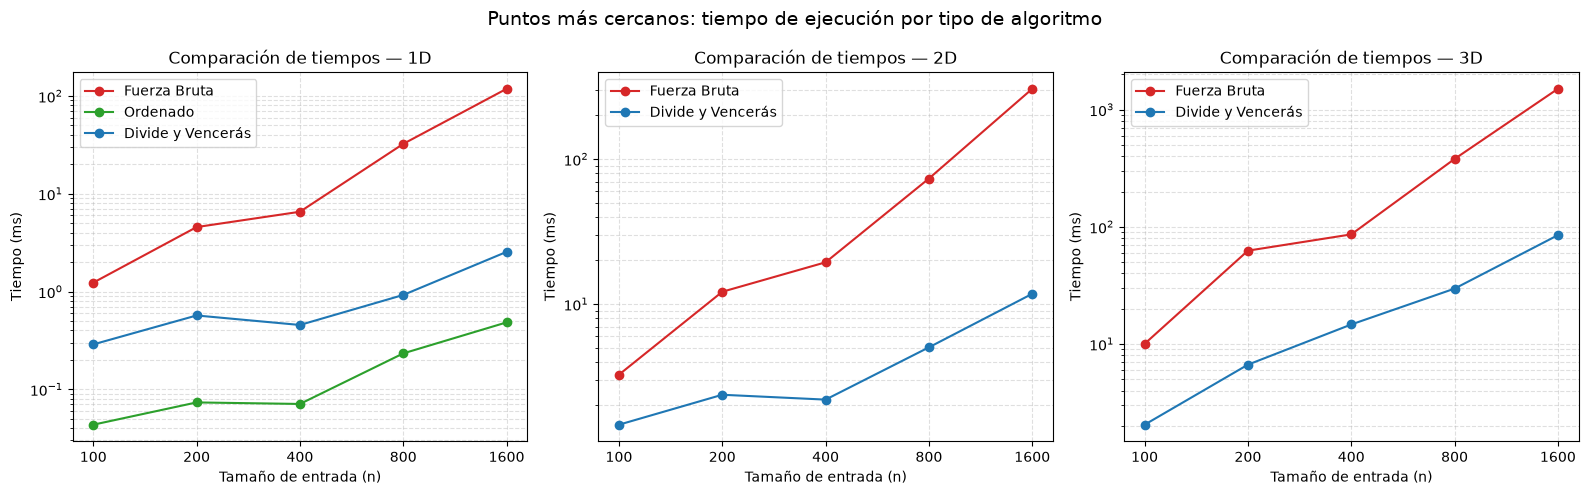

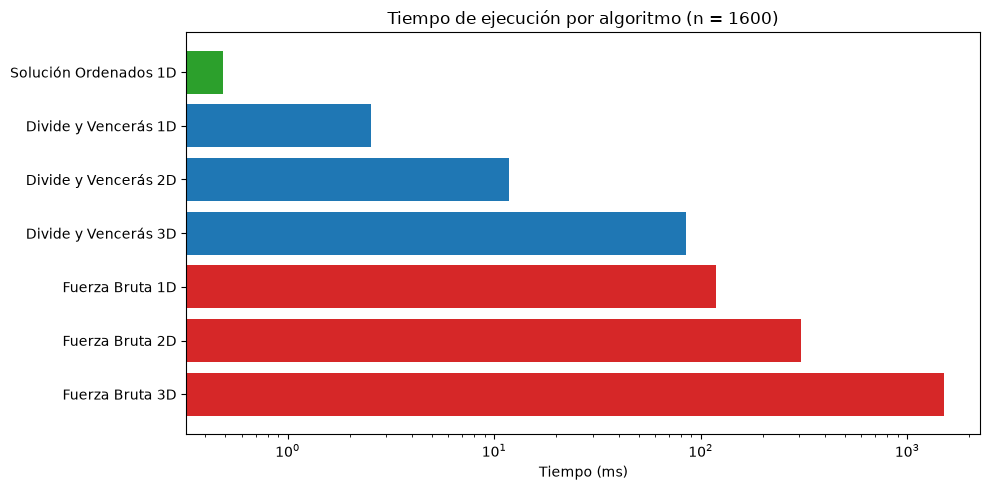

In [26]:
# Preparamos los datos a partir del DataFrame de resultados ya calculado.
# Usamos directamente la lista "tamanios" para el eje x (en vez de len(Datos
# entrada)) para que las 5 muestras (100, 200, 400, 800, 1600) queden siempre
# bien alineadas y equiespaciadas, sin depender de la longitud real de cada entrada.
df_plot = df.reset_index()
df_plot["Dimensión"] = df_plot["Algoritmo"].str.extract(r"(\d+D)")
df_plot["Tipo"] = df_plot["Algoritmo"].apply(
    lambda s: "Fuerza Bruta" if "Fuerza Bruta" in s
    else ("Ordenado" if "Ordenados" in s else "Divide y Vencerás")
)

# A cada fila le asignamos el tamaño de "tamanios" que le corresponde según
# el orden en el que se generó (cada n produce 7 filas seguidas: 3 de 1D, 2 de 2D, 2 de 3D).
filas_por_iteracion = 7
df_plot["Tamaño (n)"] = df_plot.index.map(
    lambda i: tamanios[i // filas_por_iteracion]
)

colores = {"Fuerza Bruta": "tab:red", "Divide y Vencerás": "tab:blue", "Ordenado": "tab:green"}
dimensiones = ["1D", "2D", "3D"]
posiciones = list(range(len(tamanios)))  # eje x equiespaciado: 0,1,2,3,4

# --- Gráfico 1: evolución del tiempo vs tamaño de entrada, por dimensión y tipo ---
fig, axes = plt.subplots(1, 3, figsize=(16, 5), sharey=False)

for ax, dim in zip(axes, dimensiones):
    subset = df_plot[df_plot["Dimensión"] == dim]
    for tipo in subset["Tipo"].unique():
        datos_tipo = subset[subset["Tipo"] == tipo].sort_values("Tamaño (n)")
        x_pos = [tamanios.index(n) for n in datos_tipo["Tamaño (n)"]]
        ax.plot(
            x_pos, datos_tipo["Tiempo (ms)"],
            marker="o", label=tipo, color=colores.get(tipo)
        )
    ax.set_title(f"Comparación de tiempos — {dim}")
    ax.set_xlabel("Tamaño de entrada (n)")
    ax.set_ylabel("Tiempo (ms)")
    ax.set_xticks(posiciones)
    ax.set_xticklabels(tamanios)
    ax.set_yscale("log")
    ax.legend()
    ax.grid(True, which="both", linestyle="--", alpha=0.4)

plt.suptitle("Puntos más cercanos: tiempo de ejecución por tipo de algoritmo", fontsize=14)
plt.tight_layout()
plt.show()

# --- Gráfico 2: comparativa de barras para el mayor tamaño de entrada ---
n_max = max(tamanios)
subset_max = df_plot[df_plot["Tamaño (n)"] == n_max].sort_values("Tiempo (ms)")

plt.figure(figsize=(10, 5))
plt.barh(
    subset_max["Algoritmo"], subset_max["Tiempo (ms)"],
    color=[colores.get(t, "gray") for t in subset_max["Tipo"]]
)
plt.xlabel("Tiempo (ms)")
plt.title(f"Tiempo de ejecución por algoritmo (n = {n_max})")
plt.xscale("log")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()
